<table style="width:100%; border-bottom: 2px solid #ccc; margin-bottom: 20px;">
  <tr>
    <td style="vertical-align:middle;">
      <img src="../../resources/ADI-Logo-RGB-FullColor.png" alt="Company Logo" height="30">
    </td>
    <td style="text-align:right; vertical-align:middle;">
      <p style="margin: 0;">Phased Array Systems</p>
      <p style="font-size: 14px; margin: 0;">Iain Derrington – ADEF Group, ADI</p>
      <p style="font-size: 12px; color: #555;">Field Applications & Platform Engineer</p>
    </td>
  </tr>
</table>

# 1. Introduction

This notebook explores the **fundamental principles of phased array systems** using interactive Python demonstrations. We'll build intuition for how antenna arrays work, why they're powerful, and the trade-offs involved in their design.

**What You'll Learn:**
- How phased arrays steer beams electronically
- The mathematics linking phase shifts to steering angles
- Array patterns, sidelobes, and grating lobes
- Tapering techniques for beam shaping
- Quantitative performance metrics (HPBW, SLL, directivity)

**Interactive Tools:**
This notebook uses **Jupyter widgets** to let you explore array behavior in real time — adjust parameters and instantly see the results.

---

## About the Presenter

**Iain Derrington** — FAE and Platforms Engineer, ADEF Group at Analog Devices (ADI)

**Background:**
- 10–15 years as electronic design engineer (ADEF, optical communications)
- 10 years in firmware development
- Currently in sales and applications engineering (since 2023)

**Outside of Work:**
- Board game enthusiast (80+ games)
- Mountain biker (e-bike enabled)
- Guitar player

---

## Useful Links

- [CN-0566 Product Page](https://www.analog.com/en/resources/reference-designs/circuits-from-the-lab/cn0566.html#rd-overview)
- [CN-0566 Wiki Page](https://wiki.analog.com/resources/eval/user-guides/circuits-from-the-lab/cn0566)
- [Jon Kraft YouTube Channel](https://www.youtube.com/@jonkraft)
- [LinkedIn Profile](https://www.linkedin.com/in/iderrington)

**Contact:** Iain.Derrington@analog.com, Jan.Hansford@analog.com

# 2. Phased Array Fundamentals

## Why Phased Arrays?

Phased array RADAR solves the problem of slow, inflexible, single-beam mechanical scanning — replacing it with ultra-fast, flexible, multiple-beam electronic steering that enables modern tracking, sensing, and EW systems.

**Problems Solved by Phased Arrays:**

1. **Eliminates Mechanical Scanning** — No moving parts, instant beam positioning
2. **Track Many Targets at Once** — Multiple independent beams simultaneously
3. **Instantaneous Beam Re-Pointing** — Microsecond-level agility for rapid control
4. **Fine Beam Shaping** — Adaptive beamforming and null steering
5. **Wideband Multimode Operation** — Support multiple functions (search, track, communicate)

---

## What is a Phased Array?

A phased array is a collection of antennas that work together to steer a beam of radio waves **electronically**, without physically moving the antennas.

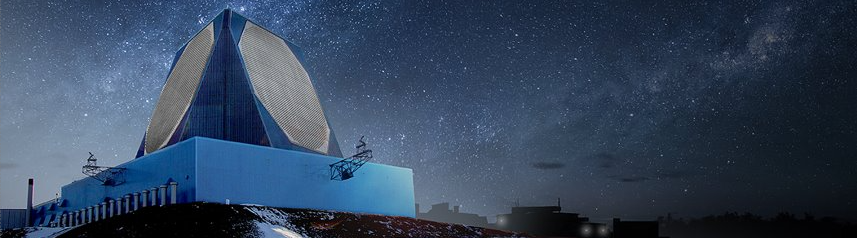

**Three Types of Phased Array Systems:**

1. **Analog** — Phase shifting done in RF domain
2. **Digital** — Each element digitized individually (AESA)
3. **Hybrid** — Mix of analog beamforming + digital sub-arrays

The **CN0566 (Phaser)** used in this presentation is a **hybrid phased array**: it has two RF ADCs sampling 2 groups of 4 signals. We'll explore this architecture in detail in later notebooks.

## Basic Principles

**Key Concepts:**

- **Pattern Multiplication:** Combining signals from multiple antennas creates a desired radiation pattern
- **Array Factor:** The combined spatial response of all array elements
- **Phase Shifting:** Adjusting the phase at each element controls beam direction electronically

The basics are straightforward and easy to visualize:

![phase_gif](resources/phased-ani.gif)

To achieve directional gain in a linear phased array, varying levels of **delay (and gain)** are added to each element. There's elegant mathematics describing the relationship between steering angle and element delay.

In this notebook, we'll use **Python** to demonstrate these principles interactively.

---

### Import Required Libraries

In [ ]:
import numpy as np                # used for working with arrays
import matplotlib.pyplot as plt   # used for creating plots


import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual, Layout,  Dropdown, IntSlider, FloatSlider
from IPython.display import display, HTML
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks, windows
plt.style.use('ggplot')

%matplotlib widget 

# 3. Mathematical Foundation

## Far-Field Assumption

When analyzing phased arrays, we assume the **far-field condition**:

$$
\Large \text{Distance} > \frac{2D^2}{\lambda}
$$

Where:
- $D$ = array aperture size (for linear array: $d \times (N-1)$)
- $\lambda$ = wavelength

**Why This Matters:**

- For **small arrays** or **low frequencies** (large λ), the far-field distance is small and easy to achieve
- For **large arrays** or **high frequencies**, far-field can be **kilometers away** — making testing and calibration challenging
- In those cases, **near-field models** are used during development, then bridged to far-field performance

---

## Phase Shift Calculation

If an RF signal arrives at a phased array from an angle **away from mechanical boresight**, the wavefront reaches each element at slightly different times.

These received signals are **phase-shifted versions** of the same waveform. To achieve **coherent summation**, we must phase-align them — essentially "undoing" the delay introduced by the wavefront's angle of arrival.

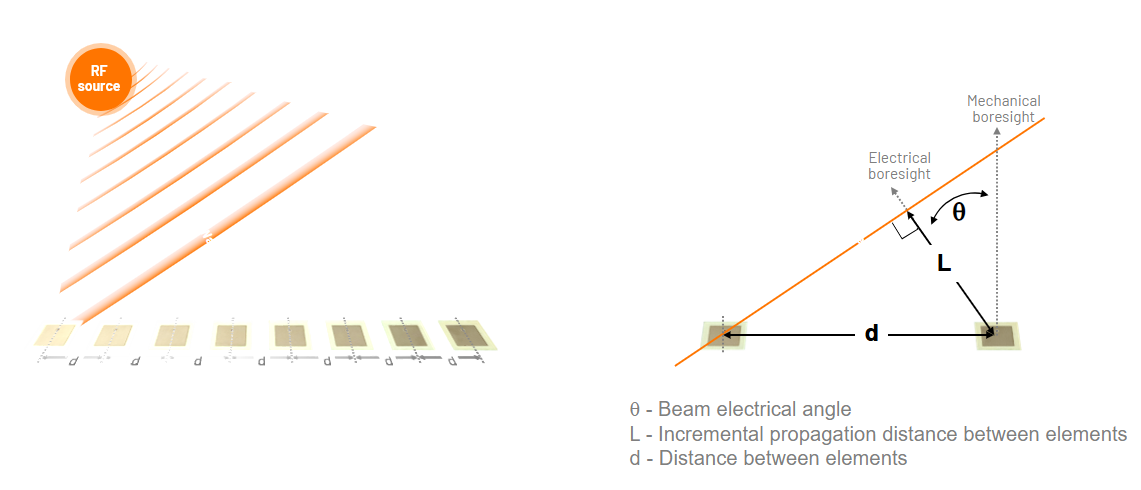

## Deriving the Phase-Angle Relationship

### Step 1: Path Length Difference

The additional path length $L$ between adjacent elements due to wavefront tilt:

The internal angle of our right triangle is $(\theta - 90°)$. From basic trigonometry:

$$
\Large \cos(x) = \frac{\text{adjacent}}{\text{hypotenuse}}
$$

$$
\Large \cos(90° - \theta) = \sin(\theta) = \frac{L}{d}
$$

Thus, the incremental distance (for the wavefront) between adjacent elements is:

$$
\Large L = d \cdot \sin(\theta)
$$

### Step 2: Convert to Time Delay

$$
\Large \Delta t = \frac{L}{c} = \frac{d \cdot \sin(\theta)}{c}
$$

Where $c$ is the speed of light.


### Step 3: Convert Time Delay to Phase

The **Phaser** kit uses vector modulators ([ADAR1000](https://www.analog.com/en/products/adar1000.html)) to implement **phase delay** rather than true time delay. A phase delay is a time delay expressed in angular notation at one particular frequency.

$$
\Large \Delta \Phi = 2\pi f \cdot \Delta t \quad \text{(radians)}
$$

Substitute $\Delta t$:

$$
\Large \Delta \Phi = \frac{2\pi f \cdot d \cdot \sin(\theta)}{c}
$$

Or, using wavelength $\lambda = c/f$:

$$
\Large \boxed{\Delta \Phi = \frac{2\pi \cdot d}{\lambda} \sin(\theta)}
$$

This is the **fundamental steering equation** for phased arrays.

## Interactive Phase Calculator

Use the slider below to see how steering angle relates to required phase shift:

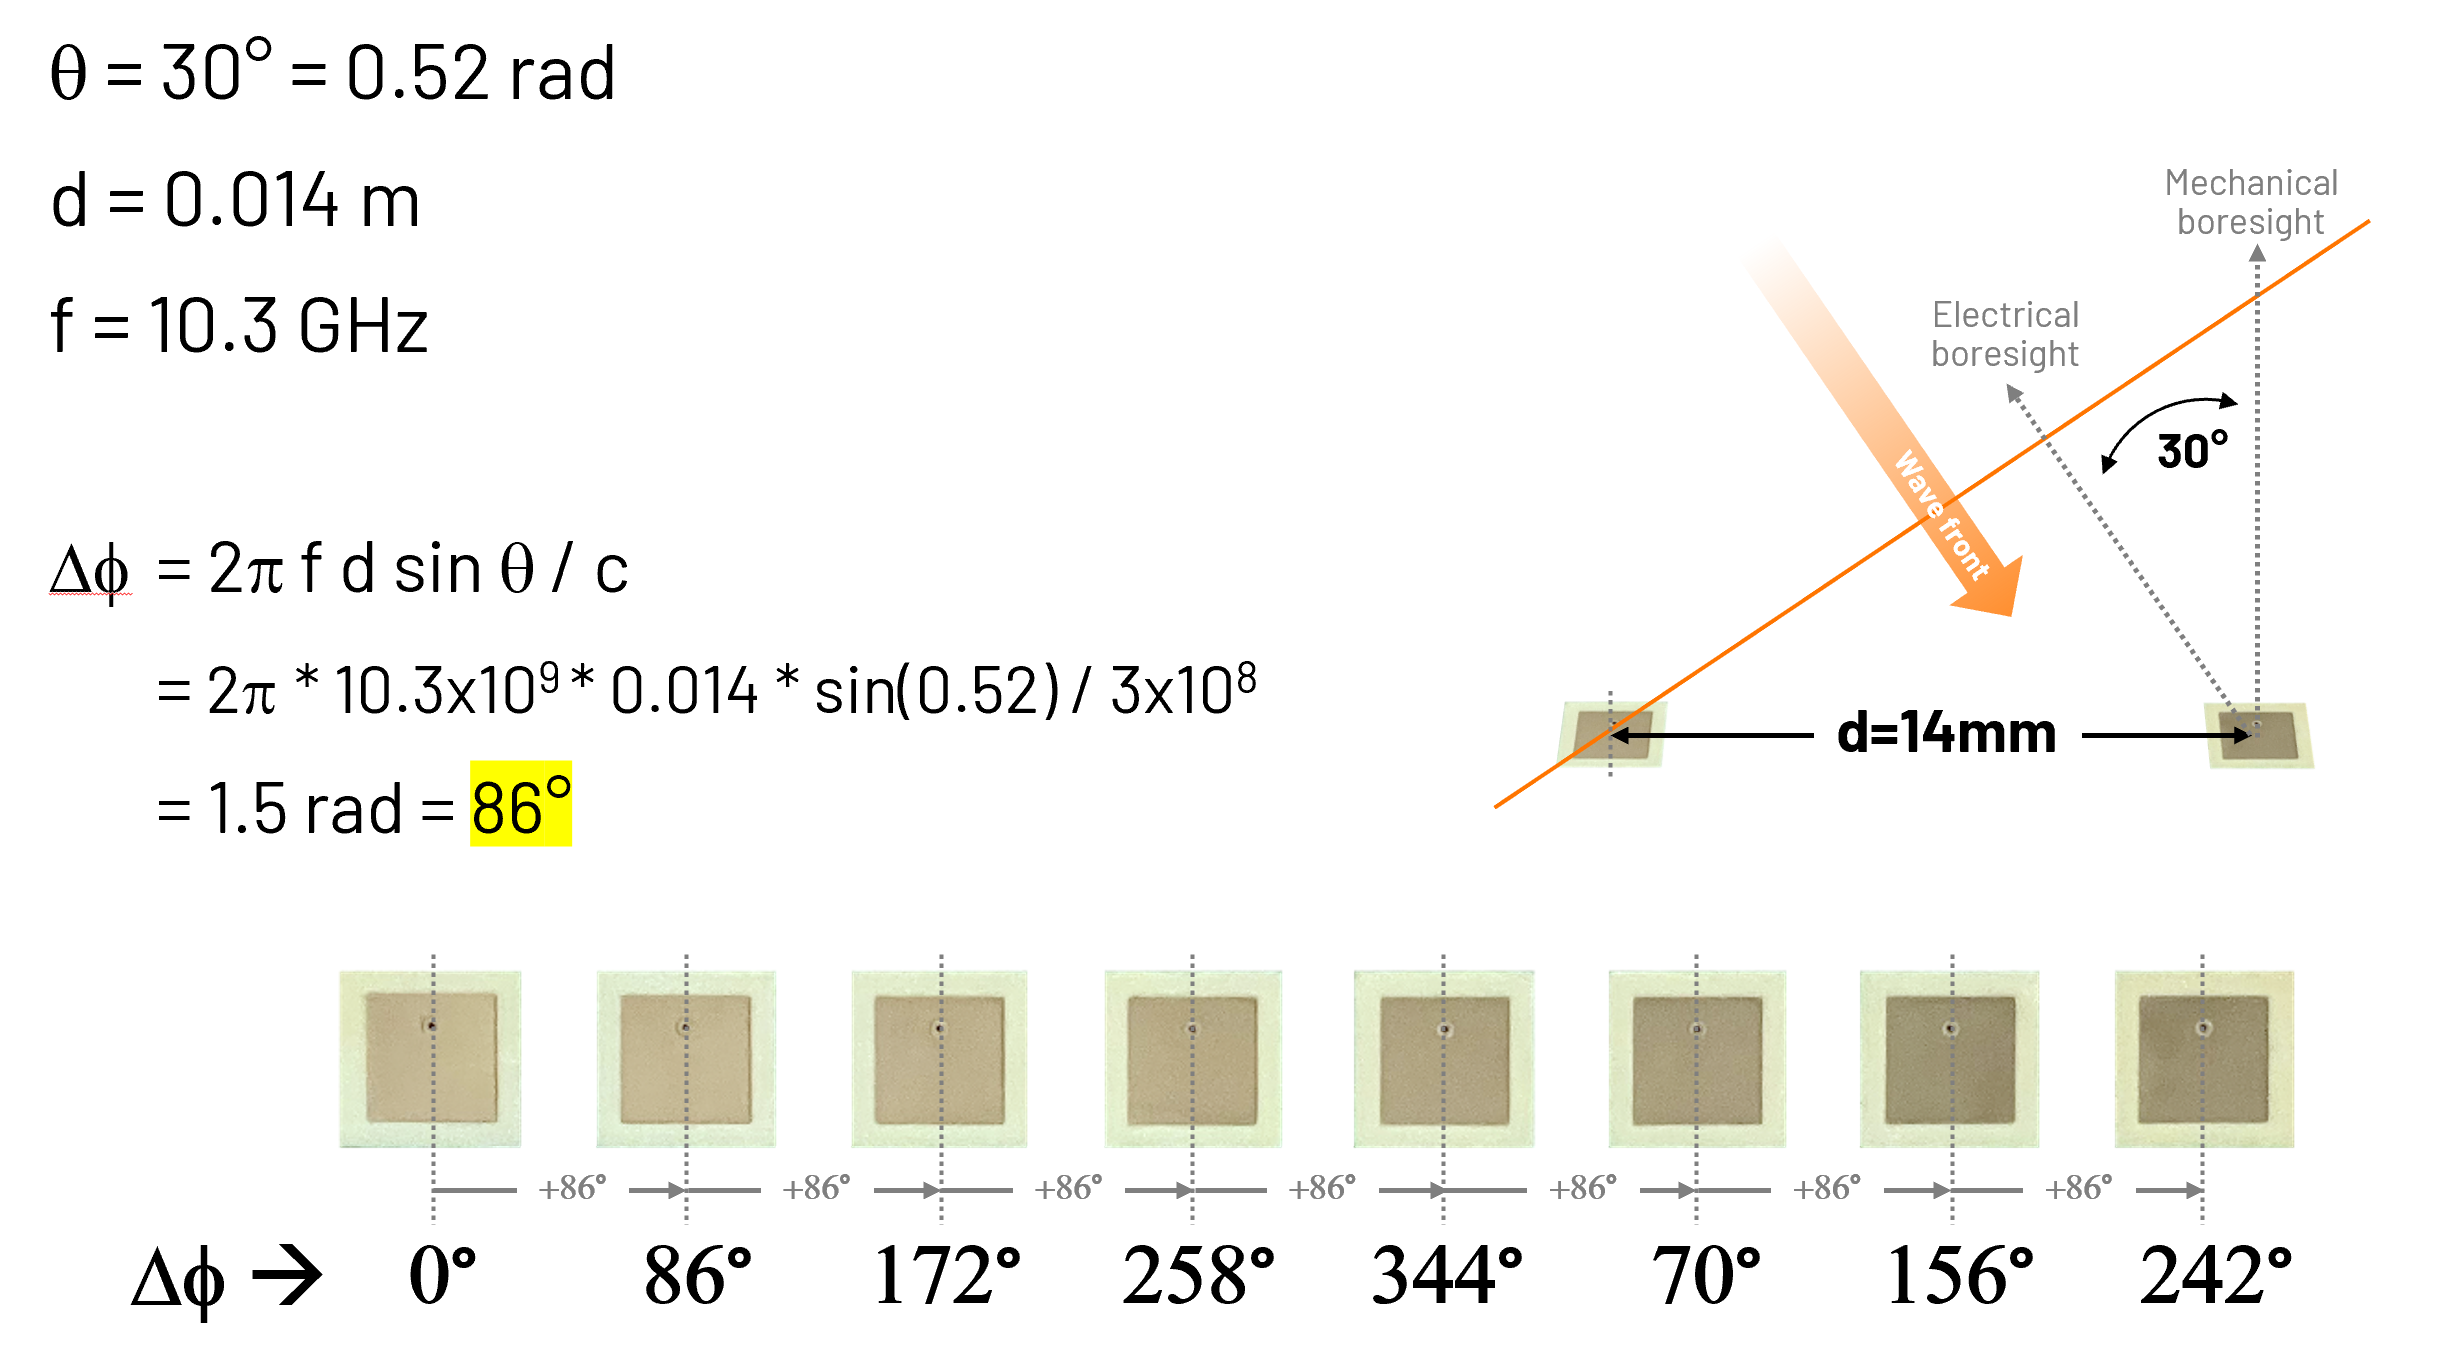

In [ ]:
""" 
Script to calculate element-to-element phase delay to achieve specified steering angle
"""

speed_of_light = 3e8  # m/s
freq = 10.3e9         # Frequency in Hz of RF signal;
phase = 0

# Detail the array
element_count = 8      # Number of elements
distance = 0.014       # The distance between each element in meters

def update(sa = 0):
    """
    Called each time the sider is moved.
    sa is the desired steering angle in degrees
    """
    
    # Calculate the phase/time difference between elements based on the steering angle and element spacing
    length = distance * np.sin( np.deg2rad(sa) )

    # Convert distance to time
    delta_t = length / speed_of_light

    # Convert delta_t into phase (radians)
    delta_phase_rad = 2 * np.pi * freq * delta_t
    delta_phase_deg = np.rad2deg(delta_phase_rad)

    text_html.value = (
        f"<hr>"
        f"<b>Steering Angle:</b> {sa}° <br>"
        f"<b>Extra path length (L):</b> {length:.6f} m <br>"
        f"<b>Time delay (Δt):</b> {delta_t:.4e} s <br>"
        f"<b>Required phase shift (Δθ):</b> <b>{delta_phase_deg:.2f}°</b> "
        f"@ {freq/1e9:.2f} GHz"
        f"<hr>"
    )
    
    display(text_html)


text_html = widgets.HTML()
sa=widgets.IntSlider(min=-90, max=90, step=1, value=0, readout_format='d', 
                     style = {'description_width': 'initial'}, 
                     description='Set Steering Angle: $$ \\theta $$',
                     layout=Layout(width='50%', height='80px'))
interact(update,sa = sa )
         

## Array Factor Theory

In the above example, setting the element-to-element phase delta to 86° gives rise to a steering angle of 30°. What does this mean?

**Question:** Does this suggest that all signals not arriving from 30° are ignored or lost?

**Answer:** No! It simply indicates that the phased array **gain** at 30° is higher than at other angles — not that other signals are eliminated.

So what determines the phased array's directional response?

---

### Antenna Pattern Components

The total gain of a phased array is determined by **two components**:

$$\Large G(\theta) = G_E(\theta) + G_A(\theta)$$

Where:
- **$G_E(\theta)$** = **Element Factor** — depends on the physical antenna element (shape, size, orientation)
- **$G_A(\theta)$** = **Array Factor** — depends on element arrangement and weights (phase + amplitude)

<div>
<img src="resources/array-pattern.png" width = "300" /><br>
</div>

---

**Key Points:**

- The **element factor** is typically fixed (can't be changed in real time) and limits performance at extreme angles
- The **array factor** can be controlled electronically by adjusting weights at each element
- **This notebook focuses on the array factor** — the electronically controllable part

### Array Factor Equation

**Fourier Transform Connection:**

A fundamental idea in phased arrays is that a **delay** in the time domain corresponds to a **phase shift** in the frequency domain.

If a signal $x(t)$ experiences a delay $\tau$, the delayed signal is:

$$\large x(t-\tau)$$

Taking the Fourier transform gives:

$$\large X(f) \cdot e^{-j2\pi f\tau}$$

This exponential term is a frequency-dependent phase rotation. So a physical delay of $\tau$ seconds is equivalent to applying:

$$\large \phi(f) = -2\pi f \tau \quad \text{radians}$$

of phase shift at frequency $f$.

---

### Summing Contributions

The array factor is the **sum of contributions** from all array elements. Each element adds the incoming signal with an increasing multiple of the phase delay:

$$\Large G_A(\theta) = e^{j0\Delta \phi} + e^{j1\Delta \phi} + e^{j2\Delta \phi} + \dots + e^{j(N-1)\Delta \phi}$$

The per-element phase shift for a signal arriving from angle $\theta$ is:

$$
\Delta \phi = \frac{2\pi f \cdot d \cdot \sin(\theta)}{c} = k \cdot d \cdot \sin(\theta)
$$

where $k = \frac{2\pi}{\lambda}$ is the **wavenumber**.

---

### Normalized Array Factor

For a general angle $\theta$ with steering to angle $\theta_0$:

$$\Large |G_A(\theta)| = \frac{\sin\left(N \left[ \frac{\pi d}{\lambda} \sin(\theta) - \frac{\Delta \phi_0}{2} \right]\right)}{N \cdot \sin\left(\frac{\pi d}{\lambda} \sin(\theta) - \frac{\Delta \phi_0}{2}\right)}$$

Where:
- $N$ = number of elements
- $d$ = spacing between elements
- $\lambda$ = wavelength
- $\Delta \phi_0$ = phase shift between adjacent elements for steering

---

Let's explore how the array pattern changes as $N$ increases using the interactive demo below:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, Layout, interact
from scipy.signal import find_peaks

# --- Constants ---
d = 0.014            # Element spacing (m)
f = 10.3e9           # Frequency (Hz)
wavelength = 3e8 / f
k = 2 * np.pi / wavelength  # Wavenumber

# --- Create persistent figure/axis once ---
fig, ax = plt.subplots(figsize=(8, 4))

# --- Interactive update function ---
def update(n=8, theta=0):
    theta_scan = np.linspace(-90, 90, 2000)  # Higher resolution for sidelobe accuracy
    theta_rad = np.radians(theta_scan)
    theta_steer = np.radians(theta)

    # Compute array factor
    af = np.zeros_like(theta_rad, dtype=complex)
    for m in range(n):
        af += np.exp(1j * k * d * m * (np.sin(theta_rad) - np.sin(theta_steer)))

    af_mag = np.abs(af)
    af_db = 20 * np.log10(af_mag / np.max(af_mag) + 1e-12)  # Normalize and convert to dB

    # --- Find peaks (in magnitude NOT dB) ---
    peaks, _ = find_peaks(af_mag, distance=50)  # distance avoids detecting noisy peaks

    # Sort peaks by height
    sorted_peaks = peaks[np.argsort(af_mag[peaks])[::-1]]

    # Main lobe is the highest peak
    main_idx = sorted_peaks[0]

    # First sidelobe = second-highest peak
    sidelobe_idx = sorted_peaks[1] if len(sorted_peaks) > 1 else None

    # Values
    sidelobe_angle = theta_scan[sidelobe_idx] if sidelobe_idx is not None else None
    sidelobe_gain_db = af_db[sidelobe_idx] if sidelobe_idx is not None else None

    # --- Clear and plot ---
    ax.cla()
    ax.plot(theta_scan, af_db, label="Array Factor (dB)")
    ax.axvline(theta, color='r', linestyle='--', label=f"Steering Angle ({theta}°)")

    # --- Label the first sidelobe ---
    if sidelobe_idx is not None:
        ax.text(
            0.02, 0.95,
            f"1st Sidelobe ≈ {sidelobe_gain_db:.1f} dB ",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.6)
        )

        # Optional: draw marker
        ax.plot(sidelobe_angle, sidelobe_gain_db, 'ro')

    # Estimate beamwidth (very rough): BW ≈ 102° / N (for broadside)
    beamwidth_deg = 102 / n
    ax.text(
        0.02, 0.88,
        f"Est. Beamwidth ≈ {beamwidth_deg:.1f}°",
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.6)
    )

    # Draw beamwidth lines
    if -90 < theta - beamwidth_deg / 2 < 90 and -90 < theta + beamwidth_deg / 2 < 90:
        ax.axvline(theta - beamwidth_deg / 2, color='g', linestyle=':', alpha=0.5)
        ax.axvline(theta + beamwidth_deg / 2, color='g', linestyle=':', alpha=0.5)

    # Final plot settings
    ax.set_title(f"Array Factor vs Steering Angle\nN = {n}, Steering = {theta}°")
    ax.set_xlabel("Angle (°)")
    ax.set_ylabel("Normalized Gain (dB)")
    ax.set_xlim(-90, 90)
    ax.set_ylim(-40, 1)
    ax.grid(True)
    ax.legend()
    fig.canvas.draw_idle()

# --- Sliders ---
sld_no_of_elements = widgets.IntSlider(
    min=2, max=64, step=1, value=8,
    style={'description_width': 'initial'},
    description='Number of elements',
    layout=Layout(width='50%', height='80px')
)

sld_theta = widgets.IntSlider(
    min=-90, max=90, step=1, value=0,
    style={'description_width': 'initial'},
    description='Steering Angle (°)',
    layout=Layout(width='50%', height='80px')
)

# --- Launch interactive plot ---
interact(update, n=sld_no_of_elements, theta=sld_theta);


### Element Factor Impact

The above plot shows only the **array factor** and ignores the **element factor**.  
The image below demonstrates the impact of including the element factor:

<img src="resources/array-factor.png" width="800"/>

---

**Observations:**

- The **main beam** decreases in amplitude with angle — this falloff is due to the **element factor**
- **Sidelobes near boresight** retain full amplitude because the element gain is still high there
- As a result, **sidelobe suppression degrades off-boresight** — the element factor reduces the main lobe more than it does the sidelobes
- For most of this notebook, we'll focus on array factor alone (element factor = constant)

# 5. Beam Shaping with Tapering

## Sidelobes and the Spatial Sampling Analogy

Taking the **Phaser** as an example, its 8 antenna elements are used to **sample the incoming wavefront**. But instead of sampling in **time** like an ADC, a **phased array samples in the spatial domain**.

To build an intuitive understanding of **sidelobes** and **tapering**, let's first revisit a similar phenomenon in the time domain — where it's more familiar.

---

## Time-Domain Windowing Analogy

When we sample a continuous-time signal using an ADC, we are:

- **Multiplying the signal by a rectangular window** (truncating it to a finite length)
- This leads to **spectral leakage** — energy spreading into nearby frequency bins in the FFT
- This appears as **sidelobes** in the frequency domain

> This happens because multiplication in the time domain (windowing) corresponds to **convolution in the frequency domain** — and the Fourier transform of a rectangular window is a **sinc function**.

We can **reduce these sidelobes** by applying a **window function** (e.g., Hamming, Hann, Blackman) to the sampled data before computing the FFT. This smooths the edges and reduces leakage — at the cost of widening the main lobe.

---

In the next cell, we'll visualize this using a simple sine wave and see how different windowing choices affect the resulting spectrum.

In [ ]:
"""
"""

# Create persistent figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

def plot_time_windowing(window_type='rectangular', freq=5, N=128):
    fs = 100  # Sampling frequency (Hz)
    t = np.linspace(0, N/fs, N, endpoint=False)
    signal = np.sin(2 * np.pi * freq * t)

    # Select window type
    if window_type == 'rectangular':
        window = np.ones(N)
    elif window_type == 'hamming':
        window = np.hamming(N)
    elif window_type == 'hann':
        window = np.hanning(N)
    elif window_type == 'blackman':
        window = np.blackman(N)
    else:
        raise ValueError("Unknown window type")

    windowed_signal = signal * window

    # FFT
    fft_len = 2048
    spectrum = np.abs(fft(windowed_signal, fft_len))[:fft_len // 2]
    freqs = fftfreq(fft_len, 1/fs)[:fft_len // 2]
    spectrum_db = 20 * np.log10(spectrum / np.max(spectrum) + 1e-12)

    # --- Update plots without creating new figures ---
    axs[0].cla()
    axs[0].plot(t, signal, label='Original Signal')
    axs[0].plot(t, windowed_signal, label='Windowed Signal')
    axs[0].plot(t, window, '--', alpha=0.5, label='Window')
    axs[0].set_title(f"Time Domain: {window_type.capitalize()} Window (Length = {N})")
    axs[0].set_xlabel("Time (s)")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].cla()
    axs[1].plot(freqs, spectrum_db)
    axs[1].set_title("Frequency Domain (FFT)")
    axs[1].set_xlim(0, fs / 2)
    axs[1].set_ylim(-80, 5)
    axs[1].set_xlabel("Frequency (Hz)")
    axs[1].set_ylabel("Magnitude (dB)")
    axs[1].grid(True)

    fig.tight_layout()
    fig.canvas.draw_idle()

# Interactive widget
interact(plot_time_windowing,
         window_type=Dropdown(options=['rectangular', 'hamming', 'hann', 'blackman'],
                              description='Window'),
         freq=IntSlider(min=1, max=20, value=5, description='Signal Frequency (Hz)'),
         N=IntSlider(min=16, max=512, step=8, value=128, description='Window Length'));


## From Time to Space: Tapering in Phased Arrays

By applying a window to the time-sampled signal, we can trade off important performance factors such as **main lobe width**, **sidelobe level**, and **dynamic range**.

These exact same principles apply to signals sampled in the **spatial domain** — i.e., a **phased array**.

> The edges of the phased array define the boundaries of a **rectangular window**. This naturally results in high sidelobes in the array's spatial response.

Just as in time-domain signal processing, we can apply **window functions** to a phased array by modifying the **amplitude (gain) of each antenna element**. Typically:
- Elements at the center remain strongest
- Elements toward the edges are tapered down toward zero

This process is known as **tapering** or **amplitude weighting**, and it shapes the array factor in the same way windowing shapes the FFT.

## Window Function Trade-offs

**Quick Reminder of Windowing Effects:**

- **Rectangular** → Good for resolving closely spaced tones, **bad** for hiding weaker tones nearby (high sidelobes)
- **Hamming / Hann** → A balance between resolution and sidelobe suppression
- **Blackman / Chebyshev** → Excellent for hiding leakage (very low sidelobes), but **poor** at resolving closely spaced sources

---

In the next section, we'll apply these windows to a spatial array and observe how they affect the **beam pattern** and **sidelobe structure**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, windows
from ipywidgets import interact, IntSlider, Dropdown

# Create persistent figure and axis
fig, ax = plt.subplots(figsize=(8, 4))

def spatial_tapering_demo(n_elements=16, taper='rectangular', steering_angle=0):
    wavelength = 3e8 / 10.3e9  # 10.3 GHz
    d = 0.014
    k = 2 * np.pi / wavelength
    theta = np.linspace(-90, 90, 2000)
    theta_rad = np.radians(theta)
    steer = np.radians(steering_angle)

    # Tapering window
    if taper == 'rectangular':
        weights = np.ones(n_elements)
    elif taper == 'hamming':
        weights = windows.hamming(n_elements)
    elif taper == 'hann':
        weights = windows.hann(n_elements)
    elif taper == 'blackman':
        weights = windows.blackman(n_elements)
    elif taper == 'chebyshev':
        weights = windows.chebwin(n_elements, at=60)
    else:
        raise ValueError("Unknown taper")

    # Array factor
    af = np.zeros_like(theta_rad, dtype=complex)
    for m in range(n_elements):
        af += weights[m] * np.exp(1j * k * m * d * (np.sin(theta_rad) - np.sin(steer)))
    af_db = 20 * np.log10(np.abs(af) / np.max(np.abs(af)) + 1e-12)

    # Plot
    ax.cla()
    ax.plot(theta, af_db)
    ax.set_title(f'{taper.capitalize()} Taper – {n_elements} Elements – Steering = {steering_angle}°')
    ax.set_xlabel("Angle (°)")
    ax.set_ylabel("Normalized Gain (dB)")
    ax.set_xlim(-90, 90)
    ax.set_ylim(-50, 5)
    ax.grid(True)

    # Beamwidth (-3 dB)
    peak_index = np.argmax(af_db)
    half_power_level = -3
    left = np.where(af_db[:peak_index] <= half_power_level)[0]
    right = np.where(af_db[peak_index:] <= half_power_level)[0]
    if left.size > 0 and right.size > 0:
        beam_left = theta[left[-1]]
        beam_right = theta[peak_index + right[0]]
        beamwidth = beam_right - beam_left
        ax.axvline(beam_left, color='g', linestyle='--', alpha=0.5)
        ax.axvline(beam_right, color='g', linestyle='--', alpha=0.5)
        ax.text(0.02, 0.95, f"Beamwidth ≈ {beamwidth:.1f}°", transform=ax.transAxes,
                fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6))

    # First Sidelobe Level (relative to main lobe)
    peaks, _ = find_peaks(af_db)
    sidelobe_peaks = [p for p in peaks if abs(p - peak_index) > 20]  # exclude main lobe ±20 samples

    if sidelobe_peaks:
        first_sll_idx = sidelobe_peaks[np.argmax(af_db[sidelobe_peaks])]
        sll = af_db[first_sll_idx]
        sll_angle = theta[first_sll_idx]
        ax.plot(sll_angle, sll, 'ro')
        ax.text(0.02, 0.88, f"1st Sidelobe ≈ {sll:.1f} dB ", transform=ax.transAxes,
                fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6))

    fig.tight_layout()
    fig.canvas.draw_idle()

# Interactive widget
interact(spatial_tapering_demo,
         n_elements=IntSlider(min=4, max=32, value=8, step=1, description='Elements'),
         taper=Dropdown(options=['rectangular', 'hamming', 'hann', 'blackman', 'chebyshev'], description='Window'),
         steering_angle=IntSlider(min=-60, max=60, value=0, step=1, description='Steering (°)'));


# 4. Beam Characteristics

## Grating Lobes and Element Spacing

Phased arrays sample the wavefront in the **spatial domain**, just like an ADC samples signals in the **time domain**.

In time-domain systems, **sampling rate** determines whether aliasing occurs. Similarly, in phased array systems, **element spacing** determines whether unwanted spatial aliasing — known as **grating lobes** — appears.

One of the most important design constraints is the **element spacing**. You may have noticed that in all previous examples, we used:

$$
\Large d = \frac{\lambda}{2}
$$

This was no accident.

---

### Why Half-Wavelength Spacing?

Using $d = \lambda/2$ ensures that:

- The array forms a **single main lobe** in the desired direction
- **No grating lobes** appear within the visible angular range (−90° to +90°)
- The spatial sampling matches the "Nyquist rate" for wavefronts

### What Are Grating Lobes?

Grating lobes are **undesired beams** that appear when the element spacing becomes too large relative to the signal wavelength.

They are **replicas of the main lobe**, appearing at other angles — similar to **aliasing** in digital sampling.

---

### Time-Space Analogy

| Time Domain (DSP) | Spatial Domain (Phased Array) |
|-------------------|-------------------------------|
| Sampling a waveform | Sampling a wavefront |
| Nyquist rate: $f_s > 2f_{\text{max}}$ | Spacing: $d < \lambda/2$ |
| Aliasing | Grating lobes |

> If element spacing $d > \lambda/2$, multiple steering angles satisfy the same phase difference — causing **multiple beams**.

### Grating Lobe Condition

The **grating lobe condition**:

$$
\Large d \leq \frac{\lambda}{1 + |\sin(\theta_{\text{steer}})|}
$$

This ensures that **no grating lobe** appears in the visible region (−90° to +90°).

For **broadside steering** ($\theta = 90°$), this simplifies to:

$$
\Large d \leq \frac{\lambda}{2}
$$

### Design Implications

**Real-World Trade-offs:**

- Large element spacing can be tempting to **reduce channel count or cost**, but it comes at the risk of unwanted lobes
- If you must space elements more widely, use:
  - **Subarrays** with overlapping coverage
  - **Randomized arrays** to spread grating lobe energy
  - **Non-uniform spacing** to break periodicity

Let's explore this interactively by varying $d$ in the array pattern simulation below:

In [ ]:
# --- Persistent figure ---
fig, ax = plt.subplots(figsize=(10, 5))

# --- Update function ---
def plot_array_factor_with_spacing(d=14, N=8, theta0_deg=0):
    ax.cla()  # Clear previous plot

    d = d / 1000  # Convert mm to meters
    c = 3e8
    wavelength = c / 10.3e9
    k = 2 * np.pi / wavelength
    theta = np.linspace(-90, 90, 2000)
    theta_rad = np.deg2rad(theta)
    theta0_rad = np.deg2rad(theta0_deg)

    # Array factor calculation
    af = np.zeros_like(theta_rad, dtype=complex)
    m = np.arange(-(N-1)//2, (N+1)//2)
    for mi in m:
        af += np.exp(1j * k * d * mi * (np.sin(theta_rad) - np.sin(theta0_rad)))
    af_db = 20 * np.log10(np.abs(af) / np.max(np.abs(af)) + 1e-12)

    # Plot array factor
    ax.plot(theta, af_db, label="Array Factor")
    ax.set_title(f"Array Factor (N={N}, d={d*1e3:.1f} mm, θ₀={theta0_deg}°, λ={wavelength*1e3:.1f} mm)")
    ax.set_xlabel("Angle (degrees)")
    ax.set_ylabel("Normalized Gain (dB)")
    ax.set_xlim(-90, 90)
    ax.set_ylim(-40, 1)
    ax.grid(True)

    # Steering angle marker
    ax.axvline(theta0_deg, color='red', linestyle='--', linewidth=1.2, label='Steering Angle')

    # -13 dB threshold line
    ax.axhline(-13, color='gray', linestyle=':', linewidth=1, label='-13 dB Threshold')

    # --- Beamwidth Estimation ---
    peak_index = np.argmax(af_db)
    half_power = -3
    left = np.where(af_db[:peak_index] <= half_power)[0]
    right = np.where(af_db[peak_index:] <= half_power)[0]
    if left.size > 0 and right.size > 0:
        beam_left = theta[left[-1]]
        beam_right = theta[peak_index + right[0]]
        beamwidth = beam_right - beam_left
        ax.axvline(beam_left, color='green', linestyle=':', alpha=0.6)
        ax.axvline(beam_right, color='green', linestyle=':', alpha=0.6)
        ax.text(0.02, 0.95, f"Beamwidth ≈ {beamwidth:.1f}°", transform=ax.transAxes,
                fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))


    ax.legend()
    fig.tight_layout()
    fig.canvas.draw_idle()

# --- Sliders ---
spacing_slider = IntSlider(value=14, min=5, max=50, step=1,
    description="Element Spacing (mm)", layout=Layout(width='70%'),
    style={'description_width': 'initial'})
element_slider = IntSlider(value=8, min=2, max=64, step=1,
    description="Number of Elements", layout=Layout(width='70%'),
    style={'description_width': 'initial'})
steering_slider = IntSlider(value=0, min=-90, max=90, step=1,
    description="Steering Angle (°)", layout=Layout(width='70%'),
    style={'description_width': 'initial'})

# --- Launch Interactive ---
interact(plot_array_factor_with_spacing,
         d=spacing_slider,
         N=element_slider,
         theta0_deg=steering_slider);


# 6. Performance Metrics

When designing or analyzing a phased array, we need **quantitative measures** to compare different configurations. The following metrics formalize what we've been observing in the beam patterns.

These metrics allow us to:
- Compare different window functions objectively
- Predict array performance before building hardware
- Make design trade-offs explicit
- Optimize for specific applications (resolution vs. interference rejection)

---

## Key Metrics We'll Calculate

1. **Half-Power Beamwidth (HPBW)** — Angular resolution
2. **First Null Beamwidth (FNBW)** — Main lobe width
3. **Sidelobe Level (SLL)** — Interference rejection capability
4. **Directivity** — Spatial gain vs. omnidirectional
5. **Array Gain** — Gain vs. single element
6. **Beam Efficiency** — Power concentration in main lobe

## 1. Half-Power Beamwidth (HPBW)

**Definition:** The angular width between the two points where the beam gain drops to **-3 dB** from the peak (half power).

$$
\text{HPBW} = \theta_{+3\text{dB}} - \theta_{-3\text{dB}}
$$

**Approximation for uniform linear array (ULA) at broadside:**

$$
\text{HPBW} \approx \frac{0.886 \lambda}{N \cdot d} \text{ radians}
$$

For $d = \lambda/2$:

$$
\boxed{\text{HPBW} \approx \frac{50.8°}{N}}
$$

**Examples:**
- 8 elements: HPBW ≈ **6.4°**
- 16 elements: HPBW ≈ **3.2°**
- 32 elements: HPBW ≈ **1.6°**

**Physical Meaning:**
- Narrower beam = better angular resolution
- More elements → narrower beam
- Trade-off: narrower beam = more sensitive to pointing errors

**Window Effect:**
- Rectangular: Narrowest HPBW (~50.8°/N)
- Hamming: ~1.3× wider
- Blackman: ~1.7× wider

## 2. First Null Beamwidth (FNBW)

**Definition:** Angular width between the first nulls on either side of the main lobe.

$$
\text{FNBW} \approx \frac{2\lambda}{N \cdot d} \text{ radians}
$$

For $d = \lambda/2$:

$$
\boxed{\text{FNBW} \approx \frac{115°}{N}}
$$

**Relationship:**
- FNBW ≈ 2.3 × HPBW (for rectangular window)
- Defines the "main lobe extent"

## 3. Sidelobe Level (SLL)

**Definition:** The ratio of the **peak sidelobe power** to the **main lobe peak power**, expressed in dB.

$$
\text{SLL (dB)} = 20 \log_{10}\left(\frac{|AF_{\text{sidelobe,max}}|}{|AF_{\text{main,max}}|}\right)
$$

**Typical Values:**

| Window Type | First SLL (dB) | Main Beam Width | Application |
|-------------|----------------|-----------------|-------------|
| **Rectangular** | **-13.3 dB** | Narrowest | High resolution, low clutter |
| **Hamming** | **-42 dB** | Moderate | General purpose |
| **Hann** | **-31 dB** | Moderate | Good balance |
| **Blackman** | **-58 dB** | Widest | High clutter/interference |
| **Chebyshev** | **Adjustable** | Design-dependent | Custom requirements |

**Design Implication:**
- High sidelobes (e.g., -13 dB) → interference and clutter leak through
- Low sidelobes (e.g., -58 dB) → wider main beam (resolution loss)

**Rule of Thumb:**
- Need -20 dB SLL → Can tolerate interferers 100× weaker than signal
- Need -40 dB SLL → Can tolerate interferers 10,000× weaker

## 4. Directivity

**Definition:** The ratio of radiation intensity in the direction of maximum gain to the **average intensity** over all directions.

For a linear array (approximation):

$$
D = \frac{4\pi}{\Omega_A} \approx \frac{2N \cdot d}{\lambda}
$$

Where $\Omega_A$ is the solid angle of the main beam.

**For $d = \lambda/2$:**

$$
\boxed{D \approx N}
$$

**In dB:**

$$
D_{\text{dB}} = 10 \log_{10}(D) \approx 10 \log_{10}(N)
$$

**Examples:**
- 8 elements: $D \approx 8$ → **9 dB**
- 16 elements: $D \approx 16$ → **12 dB**
- 64 elements: $D \approx 64$ → **18 dB**

**Physical Meaning:**
- Directivity measures how much you've "focused" the beam
- It's the spatial equivalent of antenna gain
- Directivity gain comes from **constructive interference** in the desired direction and **destructive interference** elsewhere

## 5. Array Gain

**Definition:** How much stronger the signal is when using the array compared to a single element.

$$
G_{\text{array}} = N \quad \text{(for coherent summation)}
$$

$$
\boxed{G_{\text{array (dB)}} = 10 \log_{10}(N)}
$$

**Examples:**
- 8-element array: **9 dB** gain over single element
- 16-element array: **12 dB** gain
- 32-element array: **15 dB** gain

**This assumes:**
- Perfect phase alignment (no steering errors)
- Uniform amplitude weighting
- Lossless combining
- Signal arriving from steered direction

**Why This Matters:**
- **9 dB gain** = detecting signals **8× weaker** than single element threshold
- Equivalent to **8× increase in transmit power** (for RADAR)
- Or **2.8× increase in detection range** (for RADAR, due to R⁴ law)

## 6. Beam Efficiency

**Definition:** The ratio of power in the **main lobe** to the **total radiated power**.

$$
\eta_{\text{beam}} = \frac{\int_{\text{main lobe}} |AF(\theta)|^2 d\Omega}{\int_{\text{all space}} |AF(\theta)|^2 d\Omega}
$$

**Approximation:**

$$
\eta_{\text{beam}} \approx 1 - \sum_{\text{sidelobes}} \frac{P_{\text{sidelobe}}}{P_{\text{total}}}
$$

**Typical Values:**

| Window Type | Beam Efficiency | SLL | HPBW (relative) |
|-------------|-----------------|-----|-----------------|
| Rectangular | **~90%** | -13.3 dB | 1.0× (baseline) |
| Hamming | **~73%** | -42 dB | 1.3× |
| Hann | **~67%** | -31 dB | 1.5× |
| Blackman | **~57%** | -58 dB | 1.7× |

**Physical Meaning:**
- Low efficiency → power "wasted" in sidelobes or wider main beam
- High sidelobe suppression → lower efficiency (power goes into wider main lobe)
- Trade-off: **Can't have narrow beam AND low sidelobes AND high efficiency**

## The Fundamental Trade-off

$$
\boxed{\text{Resolution} \leftrightarrow \text{Sidelobe Level} \leftrightarrow \text{Efficiency}}
$$

You can optimize for **two** of these, but not all three:

| Optimize For | Window | HPBW | SLL | Efficiency |
|--------------|--------|------|-----|------------|
| **Resolution** | Rectangular | ✓ Narrow | ✗ High (-13 dB) | ✓ High (90%) |
| **Sidelobe Rejection** | Blackman | ✗ Wide | ✓ Low (-58 dB) | ✗ Low (57%) |
| **Balance** | Hamming | ○ Medium | ○ Medium (-42 dB) | ○ Medium (73%) |

**Design Guidelines:**
- **Low-clutter environment** (e.g., space, high altitude) → Use rectangular (resolution priority)
- **High-clutter environment** (e.g., ground-based, urban) → Use Blackman/Chebyshev (rejection priority)
- **General purpose** → Use Hamming (balanced)

# 7. Summary

In this notebook, we've introduced the core concepts behind **phased array radar**:

**What We've Covered:**

1. **Phased Array Fundamentals**
   - Why phased arrays replace mechanical scanning
   - Electronic beam steering principles
   - Pattern multiplication: Element Factor + Array Factor

2. **Mathematical Foundation**
   - Phase-to-angle relationship: $\Delta\Phi = \frac{2\pi d}{\lambda}\sin(\theta)$
   - Array factor equation and sinc-like response
   - Far-field assumptions

3. **Beam Characteristics**
   - Grating lobes and the spatial Nyquist criterion ($d \leq \lambda/2$)
   - Element spacing constraints
   - Time-space analogy for aliasing

4. **Beam Shaping**
   - Time-domain windowing review
   - Spatial tapering (amplitude weighting)
   - Window function trade-offs (Rectangular, Hamming, Blackman)

5. **Performance Metrics**
   - HPBW ≈ 50.8°/N (resolution)
   - SLL (interference rejection)
   - Array Gain = 10log₁₀(N) dB
   - The fundamental three-way trade-off: Resolution ↔ SLL ↔ Efficiency

**Key Insights:**

- Phased arrays **sample the spatial domain** just like ADCs sample time
- Element-to-element delay translates to **phase shifts** for beam steering
- The array factor resembles a **sinc function** due to rectangular windowing in space
- **Tapering** controls sidelobes at the cost of resolution (same as FFT windowing)
- **No free lunch:** You can optimize for resolution, sidelobe rejection, OR efficiency — but not all three

---

## Next Steps

In the next notebook (**2_PhaserHardware.ipynb**), we'll explore the **CN0566 Phaser** platform:
- ADAR1000 beamformer architecture
- ADF4159 chirp generation
- PlutoSDR transceiver
- System integration and signal flow